**Module** : CCS4340 - Machine Learning

**Activity** : Lab Sheet 1 - Linear Regression

**Submitted by** : CIT-23-02-0162 | Jayani Sashikala

**Date of submission** : 2025/12/14

# Task D1 - Data Loading & Exploration

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("House_Prices.csv")

# Display first 5 rows
print(df.head())

   Area (sqft)  Bedrooms  Age (years)  Price (Lakhs)
0         1000         2           10             65
1          800         1           15             48
2         1200         3            8             85
3         1500         4            5            120
4          900         2           12             60


In [4]:
# Dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Area (sqft)    20 non-null     int64
 1   Bedrooms       20 non-null     int64
 2   Age (years)    20 non-null     int64
 3   Price (Lakhs)  20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None


In [5]:
# Describe Dtaset
print(df.describe())

       Area (sqft)   Bedrooms  Age (years)  Price (Lakhs)
count    20.000000  20.000000    20.000000      20.000000
mean   1327.500000   2.750000     9.900000      94.450000
std     417.850074   0.966546     4.972556      36.990006
min     750.000000   1.000000     3.000000      45.000000
25%     987.500000   2.000000     5.750000      61.500000
50%    1275.000000   3.000000     9.000000      89.000000
75%    1625.000000   3.250000    14.250000     122.500000
max    2100.000000   4.000000    20.000000     165.000000


In [29]:
# Identify X (features) and y (target)
X = 'Area (sqft)', 'Bedrooms', 'Age (years)'
y = 'Price (Lakhs)'

print('Features (X) :', X)
print('Target (y) :', y)

Features (X) : ('Area (sqft)', 'Bedrooms', 'Age (years)')
Target (y) : Price (Lakhs)


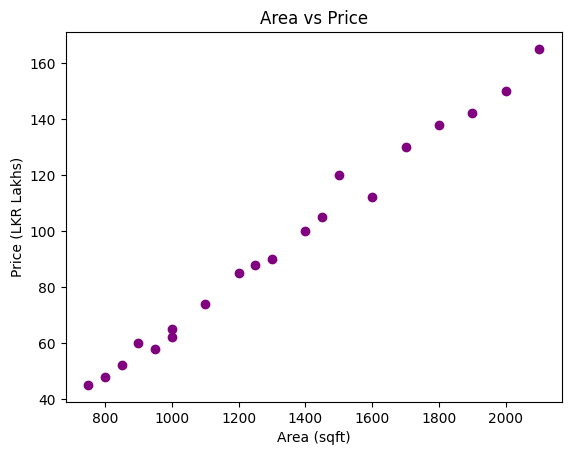

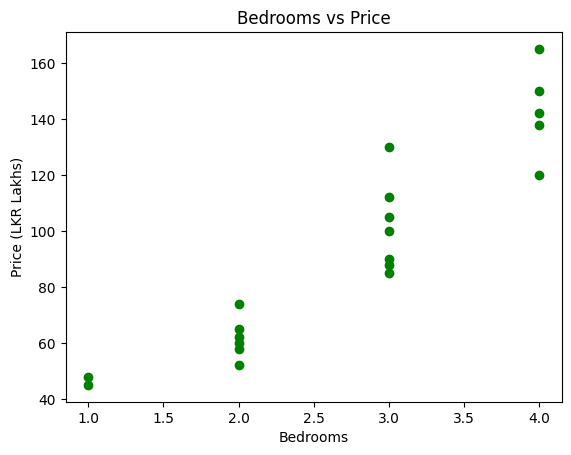

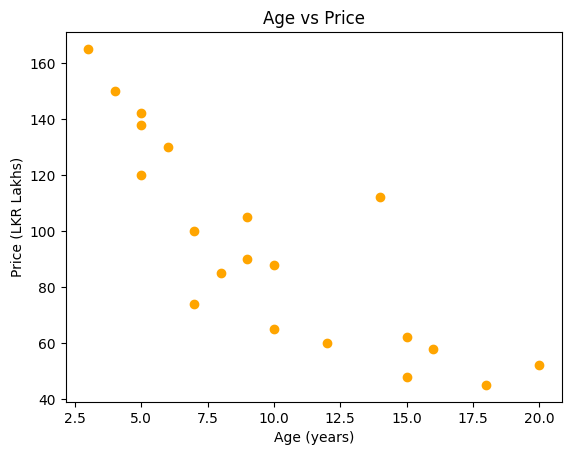

In [36]:
# Visualizing Data

# Area vs Price
plt.scatter(df['Area (sqft)'], y, color='purple')
plt.xlabel("Area (sqft)")
plt.ylabel("Price (LKR Lakhs)")
plt.title("Area vs Price")
plt.show()

# Bedrooms vs Price
plt.scatter(df['Bedrooms'], y, color='green')
plt.xlabel("Bedrooms")
plt.ylabel("Price (LKR Lakhs)")
plt.title("Bedrooms vs Price")
plt.show()

# Age vs Price
plt.scatter(df['Age (years)'], y, color='orange')
plt.xlabel("Age (years)")
plt.ylabel("Price (LKR Lakhs)")
plt.title("Age vs Price")
plt.show()


# Task D2 - Multiple Linear Regression Model Training

In [30]:
# Set features
X = df[['Area (sqft)', 'Bedrooms', 'Age (years)' ]]
y = df['Price (Lakhs)']

# Train model
model = LinearRegression()
model.fit(X, y)

# Print regression coefficients and intercept
print("Coefficients (Area (sqft), Bedrooms, Age (years)):", model.coef_)
print("Intercept (b):", model.intercept_)

Coefficients (Area (sqft), Bedrooms, Age (years)): [ 0.07802699  2.37274779 -0.52374222]
Intercept (b): -10.470835673248644


In [32]:
# Model equation
print('Model Equation ---> Price = 0.078*Area + 2.372*Bedrooms – 0.524*Age – 10.471')

Model Equation ---> Price = 0.078*Area + 2.372*Bedrooms – 0.524*Age – 10.471


# Task D3 — Model Evaluation

In [7]:
# Predict using full dataset
y_pred_all = model.predict(X)

# Print first 5 predictions
print("First 5 Predictions:", y_pred_all[:5])

First 5 Predictions: [ 67.06422621  46.46736963  86.08985613 113.44192712  58.21404292]


In [8]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred_all)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 7.85473532971768


In [9]:
from sklearn.metrics import r2_score

# Calculate R² score
r2 = r2_score(y, y_pred_all)
print("R² Score:", r2)

R² Score: 0.9939571870317728


# Task D4 — Predict New House Price

In [10]:
# Predict price for new house
new_house = ([[1600, 3, 5]])
predicted_price = model.predict(new_house)

print("Predicted Price for a new house:", predicted_price[0])


Predicted Price for a new house: 118.8718781818491


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


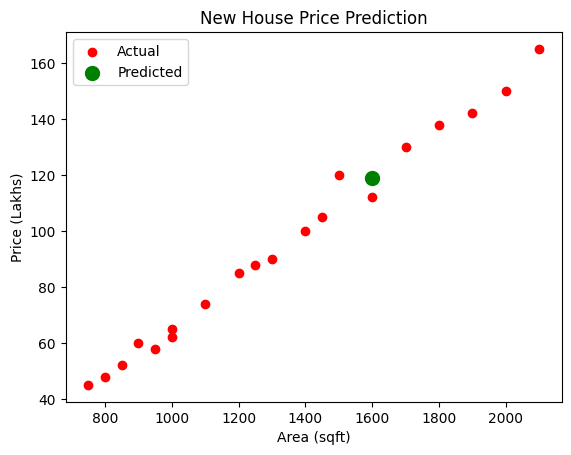

In [41]:
plt.scatter(df['Area (sqft)'], df['Price (Lakhs)'], color='red', label='Actual')
plt.scatter(new_house['Area (sqft)'], predicted_price, color='green', s=100, label='Predicted')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (Lakhs)')
plt.title('New House Price Prediction')
plt.legend()
plt.show()
